# Evaluating confidence predictor

Here, we evaluate our three confidence prediction methods and assess how well they match to poorly predicted data points.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as rt
import pandas as pd
import seaborn as sns
import torch
from torch.nn.functional import softmax

from tcr_antigen_prediction.models import TCRContactMapPredictor

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr_1as = fh['cdr_1a'][:]
    cdr_2as = fh['cdr_2a'][:]
    cdr_3as = fh['cdr_3a'][:]
    cdr_1bs = fh['cdr_1b'][:]
    cdr_2bs = fh['cdr_2b'][:]
    cdr_3bs = fh['cdr_3b'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo_sequence'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

results = pd.DataFrame(
    {
        'cdr_1a': list(cdr_1as),
        'cdr_2a': list(cdr_2as),
        'cdr_3a': list(cdr_3as),
        'cdr_1b': list(cdr_1bs),
        'cdr_2b': list(cdr_2bs),
        'cdr_3b': list(cdr_3bs),
        'peptide': list(peptides),
        'mhc': list(mhcs),
        'fold': folds,
        'non_binding': labels[:, 0],
        'binding': labels[:, 1],
    }
)

In [3]:
indices = np.arange(len(labels))

In [4]:
rng = np.random.default_rng(123)
sample_indices = rng.choice(indices, int(len(indices) * 0.1))

In [5]:
tcr_pmhcs = np.concatenate([cdr_1as, cdr_2as, cdr_3as, cdr_1bs, cdr_2bs, cdr_3bs, peptides, mhcs], axis=1)
tcr_pmhcs_flat = tcr_pmhcs.reshape(tcr_pmhcs.shape[0], -1)

In [6]:
fold_results = []
NUM_CONFIDENCE_PREDICTIONS = 5

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    fold_predictions = results.loc[sample_indices].copy()
    fold_predictions['holdout_fold'] = fold_num

    print('Loading model')
    model = TCRContactMapPredictor(drop_out_rate=0.6)
    model.load_state_dict(
        torch.load(
            f'models/TCRContactMapPredictor/model_{fold_num}.pt',
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    logits = model(
        torch.tensor(cdr_1as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_2as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_3as[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_1bs[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_2bs[sample_indices], dtype=torch.float32),
        torch.tensor(cdr_3bs[sample_indices], dtype=torch.float32),
        torch.tensor(peptides[sample_indices], dtype=torch.float32),
        torch.tensor(mhcs[sample_indices], dtype=torch.float32),
    )

    predictions = softmax(logits, dim=1)

    fold_predictions['non_binding_prediction'] = predictions[:, 0].detach().cpu().numpy()
    fold_predictions['binding_prediction'] = predictions[:, 1].detach().cpu().numpy()

    print('Making confidence prediction')
    model.train()
    for i in range(NUM_CONFIDENCE_PREDICTIONS):
        print(i + 1, 'of', NUM_CONFIDENCE_PREDICTIONS)
        confidence_logits = model(
            torch.tensor(cdr_1as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_2as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_3as[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_1bs[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_2bs[sample_indices], dtype=torch.float32),
            torch.tensor(cdr_3bs[sample_indices], dtype=torch.float32),
            torch.tensor(peptides[sample_indices], dtype=torch.float32),
            torch.tensor(mhcs[sample_indices], dtype=torch.float32),
        )
        confidence_prediction = softmax(confidence_logits, dim=1)

        fold_predictions[f'confidence_prediction_{i}_non_binding'] = confidence_prediction[:, 0].detach().cpu().numpy()
        fold_predictions[f'confidence_prediction_{i}_binding'] = confidence_prediction[:, 1].detach().cpu().numpy()

    print('Making confidence prediction from regressor')
    sess = rt.InferenceSession(f'models/ConfidencePredictor/model_{fold_num}.onnx')
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    confidence, *_ = sess.run(None, {'X': tcr_pmhcs_flat[sample_indices].astype(np.float32)})
    fold_predictions['confidence_distance_regressor'] = confidence.squeeze(-1)

    fold_results.append(fold_predictions)

    print('Finished fold')

results = pd.concat(fold_results).reset_index(drop=True)

Fold: 1
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-01-29 10:49:33.738191433 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829040, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:33.742133930 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829041, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:33.748367157 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829042, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:33.753424387 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829043, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 2
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-01-29 10:49:53.939380690 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829450, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:53.944488053 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829451, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:53.949549942 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829452, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:49:53.954140129 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2829453, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 3
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


...

Finished fold
Fold: 4
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-01-29 10:50:32.286589518 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2831928, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:32.290134643 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2831929, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:32.296753430 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2831930, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:32.301811431 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2831931, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold
Fold: 5
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor


2025-01-29 10:50:50.934175009 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2832196, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:50.938143604 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2832197, index: 7, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:50.944352786 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2832198, index: 8, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-01-29 10:50:50.949408944 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 2832199, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the 

Finished fold


In [7]:
results['prediction_binary'] = (results['non_binding_prediction'] < results['binding_prediction']).apply(int)

In [8]:
results['residual_abs'] = (
    np.abs(results['binding'] - results['binding_prediction'])
    + np.abs(results['non_binding'] - results['non_binding_prediction'])
) / 2
results['residual_squared'] = (
    (results['binding'] - results['binding_prediction']) ** 2
    + (results['non_binding'] - results['non_binding_prediction']) ** 2
) / 2

In [9]:
results['correct'] = results['prediction_binary'] == results['binding']

In [10]:
results['in_training_data'] = results['fold'] != results['holdout_fold']

<Axes: xlabel='correct', ylabel='percent'>

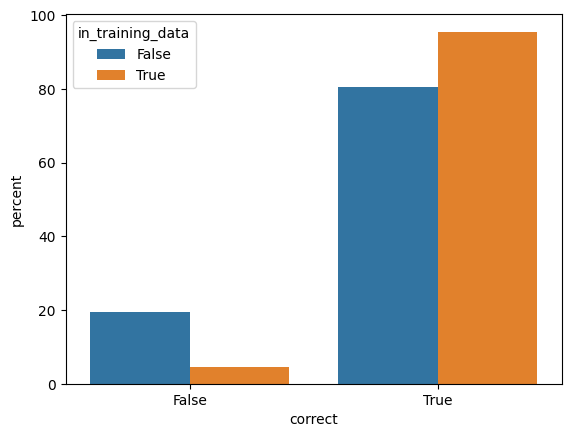

In [11]:
sns.barplot(
    results.groupby('in_training_data')['correct']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percent')
    .reset_index(),
    x='correct',
    y='percent',
    hue='in_training_data',
)

## Confidence from Max softmax probability

In [12]:
results['confidence_max_soft_max'] = np.max(
    results[['binding_prediction', 'non_binding_prediction']].to_numpy(),
    axis=1,
)

<Axes: ylabel='Frequency'>

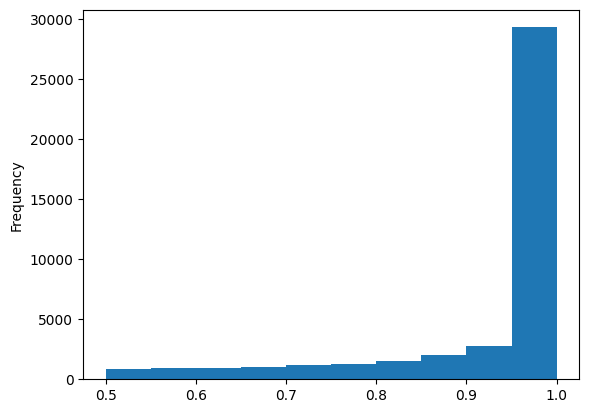

In [13]:
results['confidence_max_soft_max'].plot.hist()

<Axes: xlabel='correct', ylabel='confidence_max_soft_max'>

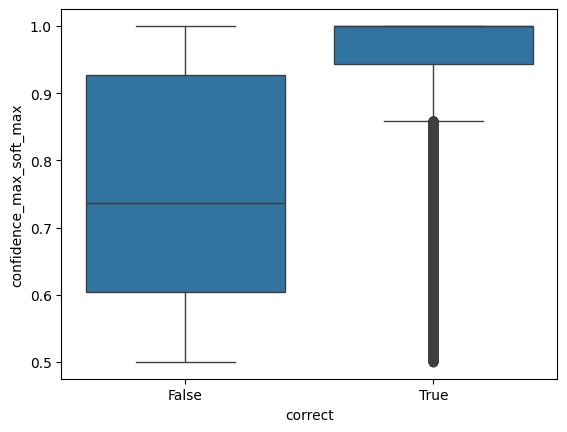

In [14]:
sns.boxplot(results, y='confidence_max_soft_max', x='correct')

<Axes: xlabel='in_training_data', ylabel='confidence_max_soft_max'>

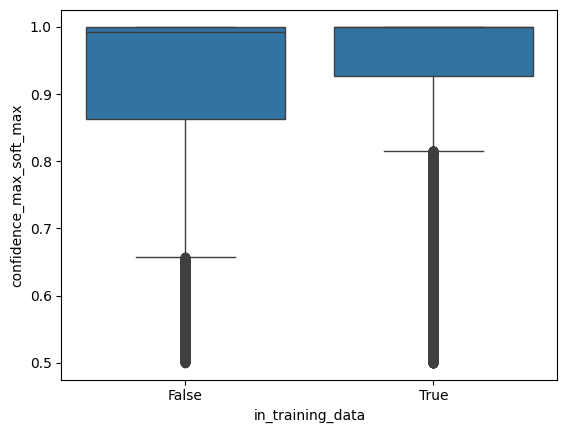

In [15]:
sns.boxplot(results, y='confidence_max_soft_max', x='in_training_data')

In [16]:
results['confidence_max_soft_max_scaled'] = 2 * results['confidence_max_soft_max'] - 1

<Axes: ylabel='Frequency'>

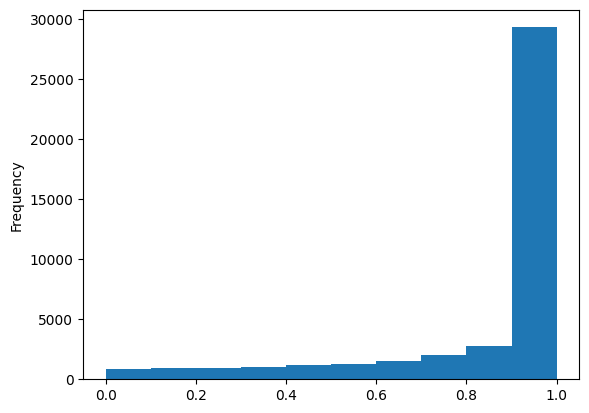

In [17]:
results['confidence_max_soft_max_scaled'].plot.hist()

<Axes: xlabel='correct', ylabel='confidence_max_soft_max_scaled'>

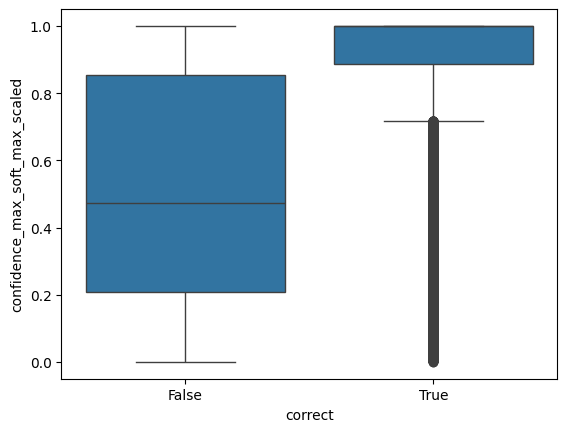

In [18]:
sns.boxplot(results, y='confidence_max_soft_max_scaled', x='correct')

<Axes: xlabel='in_training_data', ylabel='confidence_max_soft_max_scaled'>

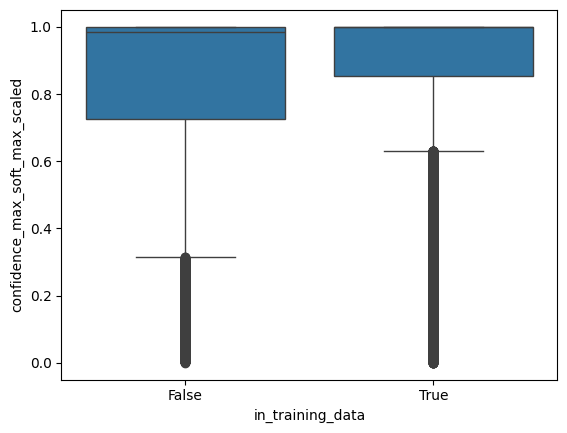

In [19]:
sns.boxplot(results, y='confidence_max_soft_max_scaled', x='in_training_data')

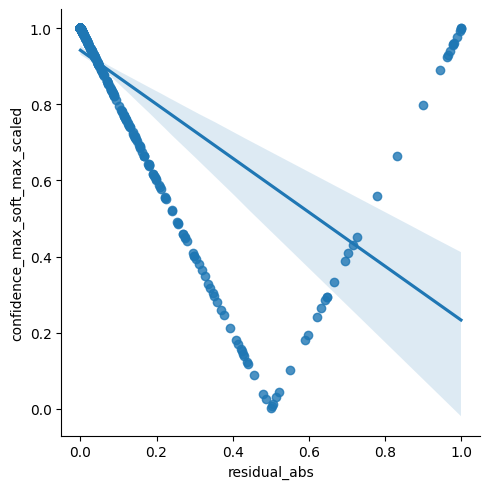

In [20]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_max_soft_max_scaled')

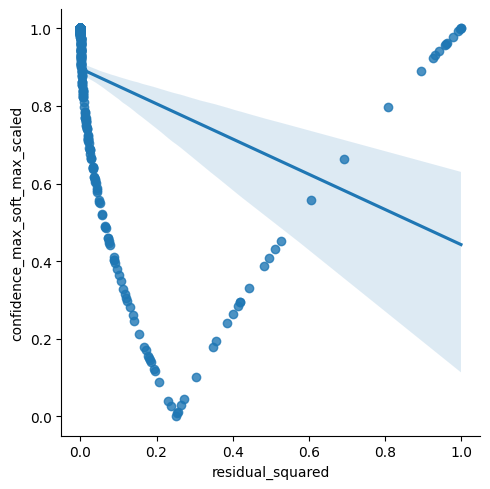

In [21]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_max_soft_max_scaled')

## Confidence from Monte-Carlo dropout

In [22]:
prediction_std = results.filter(regex=r'confidence_prediction_\d_binding').apply(np.std, axis=1)

<Axes: ylabel='Frequency'>

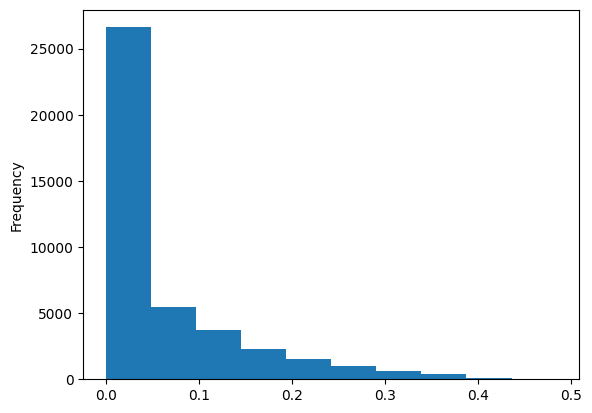

In [23]:
prediction_std.plot.hist()

In [24]:
confidence_prediction = 1 - prediction_std / prediction_std.max()

<Axes: ylabel='Frequency'>

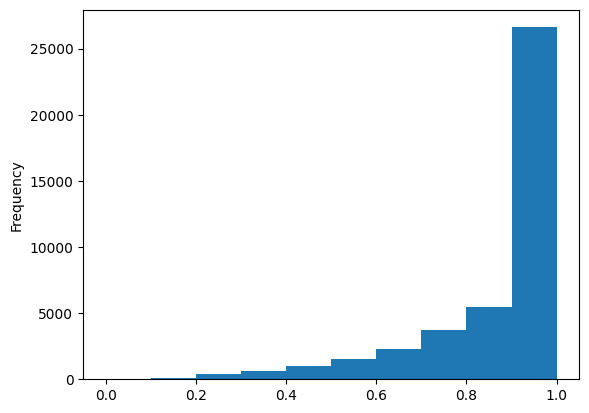

In [25]:
confidence_prediction.plot.hist()

In [26]:
results['confidence_prediction'] = confidence_prediction

<Axes: xlabel='in_training_data', ylabel='confidence_prediction'>

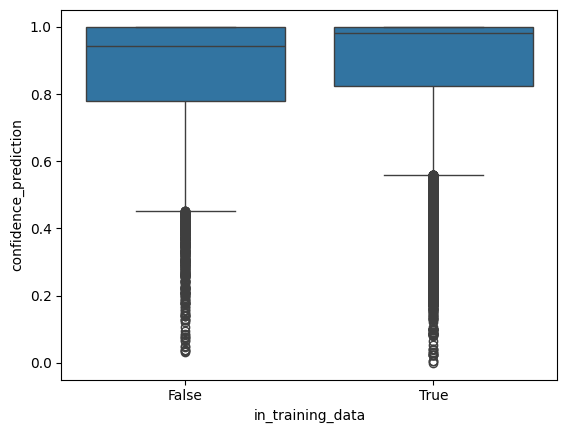

In [27]:
sns.boxplot(results, x='in_training_data', y='confidence_prediction')

<Axes: xlabel='correct', ylabel='confidence_prediction'>

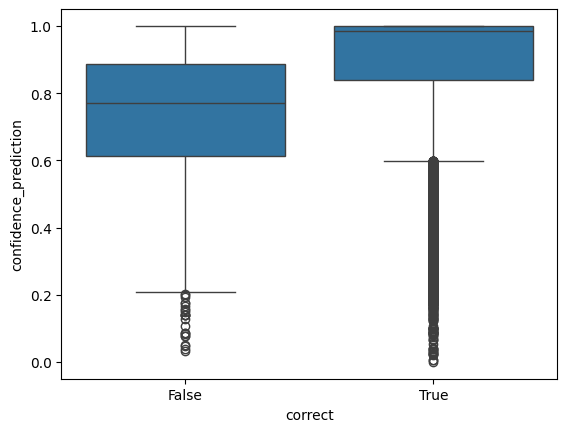

In [28]:
sns.boxplot(results, x='correct', y='confidence_prediction')

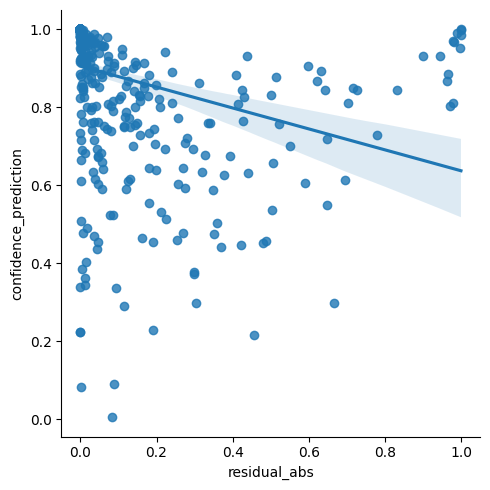

In [29]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_prediction')

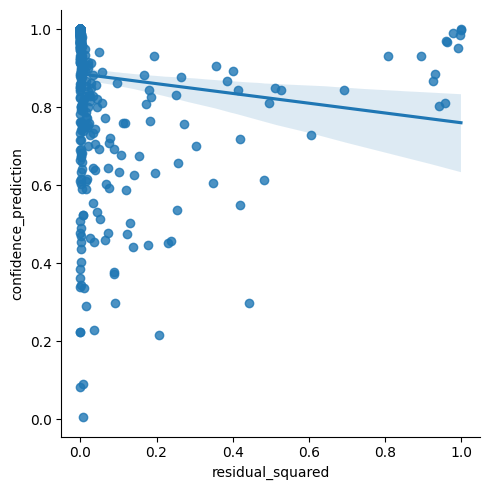

In [30]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_prediction')

## Distance Based Regressor

<Axes: xlabel='in_training_data', ylabel='confidence_distance_regressor'>

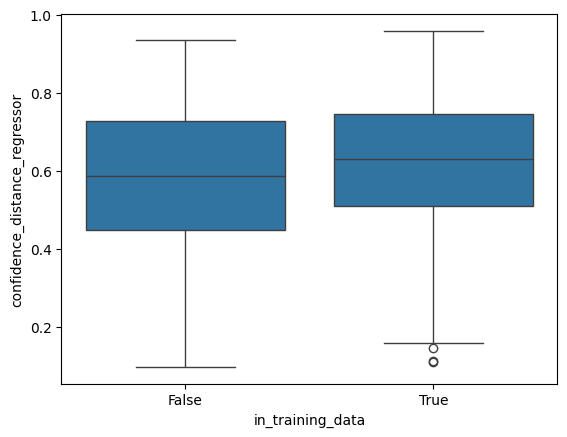

In [31]:
sns.boxplot(results, x='in_training_data', y='confidence_distance_regressor')

<Axes: xlabel='correct', ylabel='confidence_distance_regressor'>

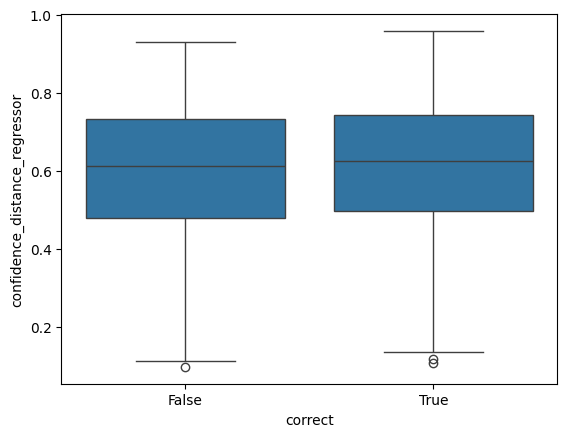

In [32]:
sns.boxplot(results, x='correct', y='confidence_distance_regressor')

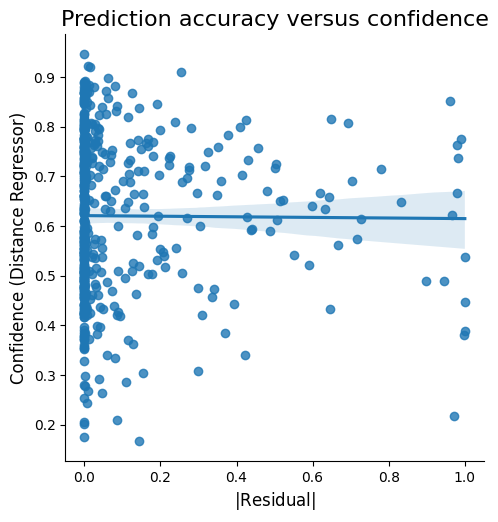

In [33]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_distance_regressor')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence (Distance Regressor)', fontsize=12)

plt.show()

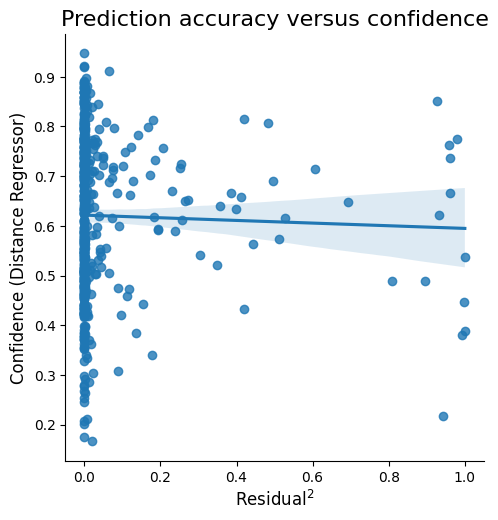

In [34]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_distance_regressor')

plt.title('Prediction accuracy versus confidence', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence (Distance Regressor)', fontsize=12)

plt.show()

## Comparison between approaches

### Correlation

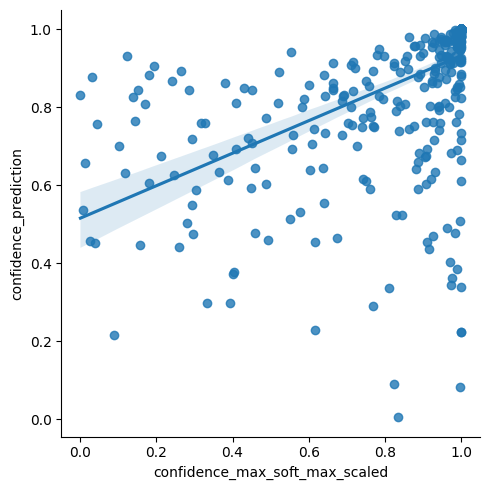

In [35]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_max_soft_max_scaled', y='confidence_prediction')

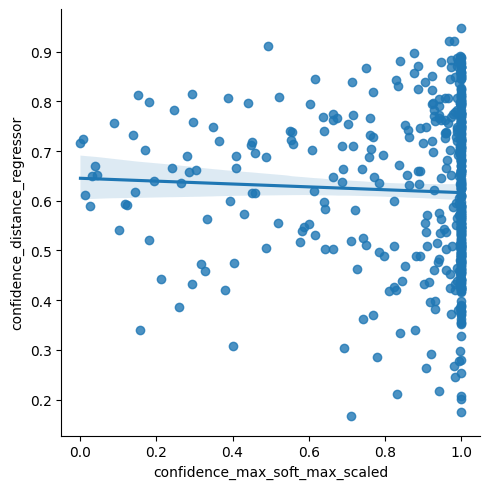

In [36]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_max_soft_max_scaled', y='confidence_distance_regressor')

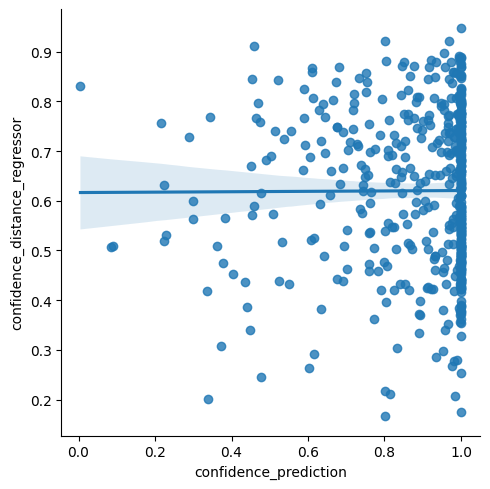

In [37]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_prediction', y='confidence_distance_regressor')

### Comparison

In [38]:
results_long = results.melt(
    id_vars=['prediction_binary', 'in_training_data', 'correct'],
    value_vars=['confidence_max_soft_max_scaled', 'confidence_prediction', 'confidence_distance_regressor'],
    var_name='method',
    value_name='confidence',
)

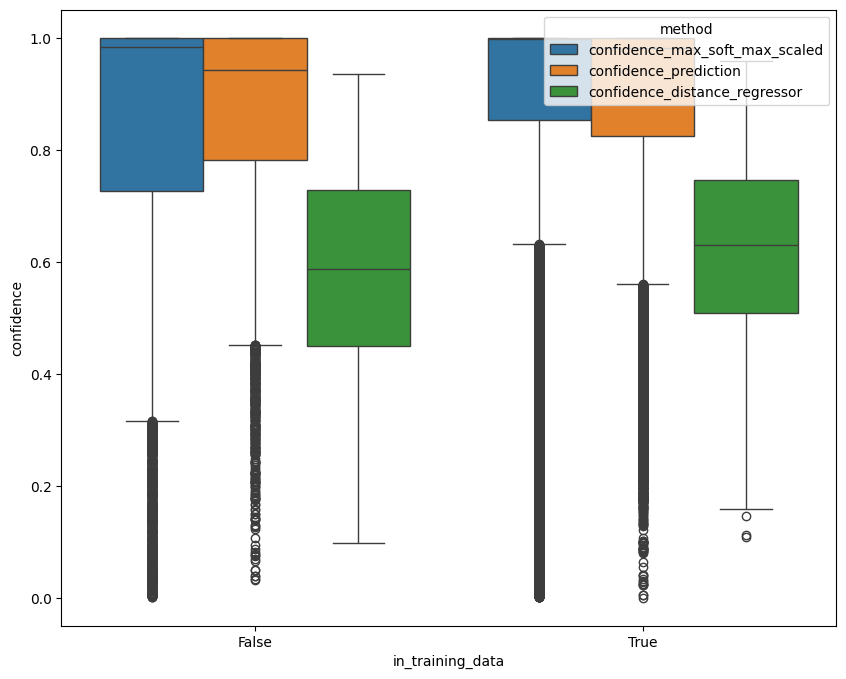

In [39]:
plt.figure(figsize=(10, 8))
sns.boxplot(results_long, x='in_training_data', y='confidence', hue='method')
plt.show()

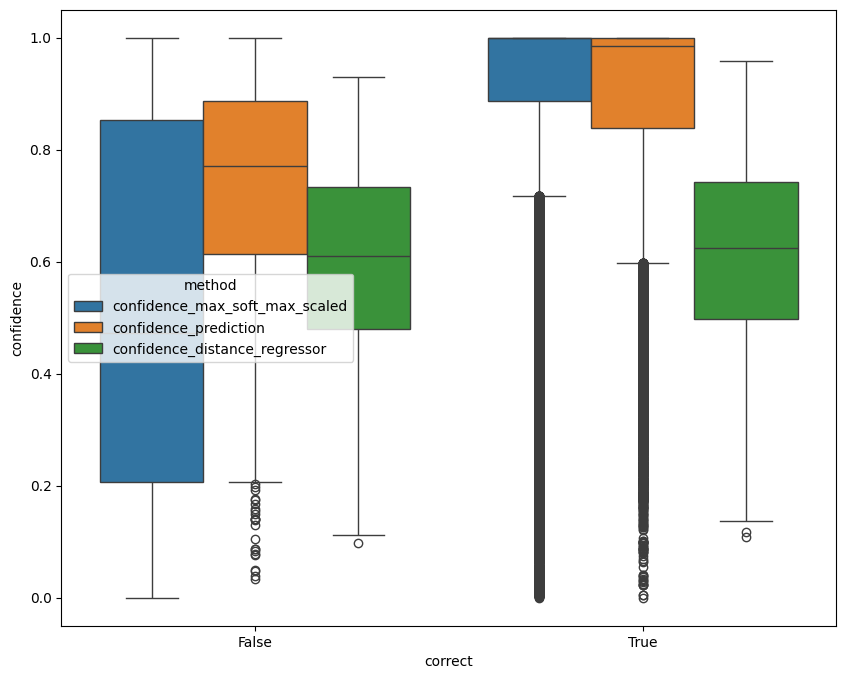

In [40]:
plt.figure(figsize=(10, 8))
sns.boxplot(results_long, x='correct', y='confidence', hue='method')
plt.show()